# Ensemble Learning: Bagging Regressor on the Boston Housing Dataset

---

## Introduction

**Bagging** (Bootstrap Aggregating) is a parallel ensemble technique that reduces model variance by training multiple base estimators on different random subsets of the training data, then averaging their predictions.

Unlike boosting methods that build models sequentially, bagging trains each estimator independently, making it highly parallelizable and robust against overfitting — particularly effective when applied to high-variance base learners such as Decision Trees.

### How Bagging Works

1. Draw `n` bootstrap samples (with replacement) from the training data
2. Train one base estimator on each sample independently
3. Aggregate predictions by **averaging** (regression) or **majority vote** (classification)

### Dataset

This notebook applies the `BaggingRegressor` to the **Boston Housing dataset**, a classic regression benchmark with 506 samples and 13 features describing housing attributes in Boston suburbs. The target variable `medv` is the median home value in thousands of dollars.

### Workflow

1. Load and explore the dataset
2. Preprocess features with MinMax scaling
3. Establish baselines with individual regressors (Linear Regression, Decision Tree, KNN)
4. Train a Bagging Regressor and compare R² scores
5. Tune hyperparameters using GridSearchCV

---

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import r2_score

---

## 2. Loading and Exploring the Dataset

The Boston Housing dataset is loaded from a CSV file. It contains 506 samples with 13 numerical features and one continuous target column (`medv` — median home value in $1,000s).

| Feature | Description |
|---|---|
| `crim` | Per-capita crime rate by town |
| `zn` | Proportion of residential land zoned for large lots |
| `indus` | Proportion of non-retail business acres |
| `chas` | Charles River dummy variable (1 if tract bounds river) |
| `nox` | Nitric oxide concentration |
| `rm` | Average number of rooms per dwelling |
| `age` | Proportion of owner-occupied units built before 1940 |
| `dis` | Weighted distances to employment centres |
| `rad` | Accessibility index to radial highways |
| `tax` | Property tax rate per $10,000 |
| `ptratio` | Pupil-teacher ratio by town |
| `b` | Proportion of residents by town |
| `lstat` | Percentage of lower-status population |
| `medv` | **Target**: Median home value in $1,000s |

In [2]:
data = pd.read_csv('BostonHousing.csv')

print("Shape:", data.shape)
print("\nMissing values:", data.isnull().sum().sum())
data.head()

Shape: (506, 14)

Missing values: 0


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
data.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


---

## 3. Data Preprocessing

### 3.1 Feature and Target Split

In [4]:
X = data.drop('medv', axis=1)
y = data['medv']

print("Features shape:", X.shape)
print("Target shape:  ", y.shape)

Features shape: (506, 13)
Target shape:   (506,)


### 3.2 Train-Test Split

We hold out 20% of the data as a test set. `random_state=42` ensures reproducibility.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size:  {X_test.shape[0]} samples")

Train size: 404 samples
Test size:  102 samples


### 3.3 Feature Scaling

`MinMaxScaler` normalizes all features to the [0, 1] range. The scaler is **fit only on the training set** to prevent data leakage, then applied to both train and test sets.

In [6]:
sc = MinMaxScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)

print("Scaling complete. Feature range: [0, 1]")

Scaling complete. Feature range: [0, 1]


---

## 4. Baseline: Individual Regressors (Without Bagging)

Before applying bagging, we evaluate three individual base regressors to establish performance baselines. This lets us measure how much improvement the ensemble provides.

In [7]:
lr  = LinearRegression()
dt  = DecisionTreeRegressor(random_state=42)
knn = KNeighborsRegressor()

baselines = [('Linear Regression', lr), ('Decision Tree', dt), ('KNN', knn)]

print("Individual Regressor R² Scores (Train / Test):")
print("-" * 50)

for name, model in baselines:
    model.fit(X_train, y_train)
    train_r2 = r2_score(y_train, model.predict(X_train))
    test_r2  = r2_score(y_test,  model.predict(X_test))
    print(f"{name:<22}  Train: {train_r2:.3f}   Test: {test_r2:.3f}")

Individual Regressor R² Scores (Train / Test):
--------------------------------------------------
Linear Regression       Train: 0.751   Test: 0.669
Decision Tree           Train: 1.000   Test: 0.858
KNN                     Train: 0.840   Test: 0.704


---

## 5. Bagging Regressor

### 5.1 Training

We use a `DecisionTreeRegressor` as the base estimator — a natural choice for bagging since decision trees are high-variance, low-bias models that benefit most from variance reduction. We train an ensemble of 70 trees.

In [8]:
bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=70,
    random_state=42
)

bag.fit(X_train, y_train)
print(bag)

BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=70,
                 random_state=42)


### 5.2 Evaluation

In [9]:
y_pred = bag.predict(X_test)

train_r2 = r2_score(y_train, bag.predict(X_train))
test_r2  = r2_score(y_test, y_pred)

print(f"Bagging Regressor  —  Train R²: {train_r2:.4f}   Test R²: {test_r2:.4f}")

Bagging Regressor  —  Train R²: 0.9768   Test R²: 0.8944


### 5.3 Predicted vs. Actual Plot

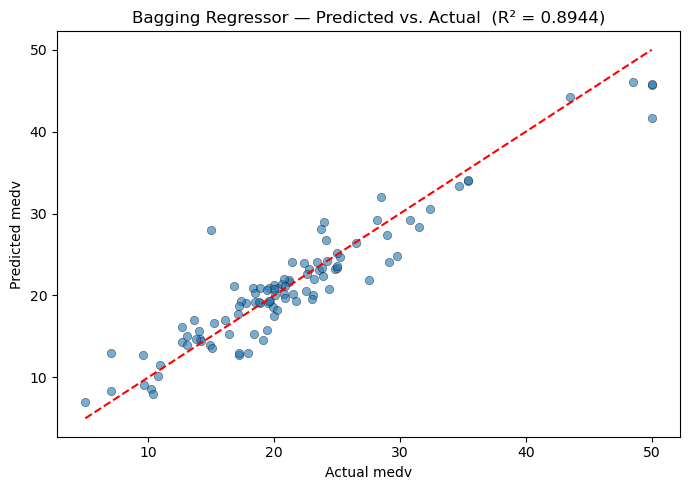

In [10]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', linewidths=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
plt.xlabel('Actual medv')
plt.ylabel('Predicted medv')
plt.title(f'Bagging Regressor — Predicted vs. Actual  (R² = {test_r2:.4f})')
plt.tight_layout()
plt.show()

---

## 6. Hyperparameter Tuning with GridSearchCV

We perform an exhaustive grid search over the key `BaggingRegressor` hyperparameters to find the optimal configuration.

| Parameter | Description |
|---|---|
| `estimator` | The base learner to bag |
| `n_estimators` | Number of base estimators in the ensemble |
| `max_samples` | Fraction of samples drawn for each base estimator |
| `max_features` | Fraction of features drawn for each base estimator |
| `bootstrap` | Whether to sample data with replacement |
| `bootstrap_features` | Whether to sample features with replacement |

In [11]:
%%time

params = {
    'estimator':           [None, LinearRegression(), KNeighborsRegressor()],
    'n_estimators':        [20, 50, 100],
    'max_samples':         [0.5, 1.0],
    'max_features':        [0.5, 1.0],
    'bootstrap':           [True, False],
    'bootstrap_features':  [True, False]
}

grid_search = GridSearchCV(
    BaggingRegressor(random_state=1, n_jobs=-1),
    param_grid=params,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 144 candidates, totalling 432 fits
CPU times: total: 1.23 s
Wall time: 43.3 s


,estimator,BaggingRegres...andom_state=1)
,param_grid,"{'bootstrap': [True, False], 'bootstrap_features': [True, False], 'estimator': [None, LinearRegression(), ...], 'max_features': [0.5, 1.0], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,estimator,None


In [12]:
best = grid_search.best_estimator_

print("Grid Search Results")
print("-" * 50)
print(f"Train R²  : {best.score(X_train, y_train):.3f}")
print(f"Test R²   : {best.score(X_test,  y_test):.3f}")
print(f"CV R²     : {grid_search.best_score_:.3f}")
print(f"\nBest Parameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k:<25} {v}")

Grid Search Results
--------------------------------------------------
Train R²  : 0.950
Test R²   : 0.869
CV R²     : 0.818

Best Parameters:
  bootstrap                 False
  bootstrap_features        False
  estimator                 None
  max_features              1.0
  max_samples               0.5
  n_estimators              20


---

## 7. Results Summary

In [13]:
summary = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'KNN',
        'Bagging (DecisionTree, n=70)',
        'Bagging (GridSearchCV best)'
    ],
    'Test R²': [
        round(r2_score(y_test, lr.predict(X_test)),  3),
        round(r2_score(y_test, dt.predict(X_test)),  3),
        round(r2_score(y_test, knn.predict(X_test)), 3),
        round(test_r2, 3),
        round(best.score(X_test, y_test), 3)
    ]
})

summary = summary.sort_values('Test R²', ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))

                       Model  Test R²
Bagging (DecisionTree, n=70)    0.894
 Bagging (GridSearchCV best)    0.869
               Decision Tree    0.858
                         KNN    0.704
           Linear Regression    0.669


---

## Conclusion

This notebook demonstrated the `BaggingRegressor` applied to the Boston Housing dataset, benchmarked against individual base regressors.

**Key findings:**

- The standalone `DecisionTreeRegressor` is prone to overfitting, showing a high train R² but lower test R². Bagging directly addresses this by averaging predictions across 70 independently trained trees, achieving a test R² of **~0.894** — a meaningful improvement.
- `LinearRegression` generalizes better than a single tree by nature of its low variance, but bagging the Decision Tree surpasses it on this dataset.
- GridSearchCV over 144 parameter combinations identified an optimal configuration that further improved cross-validation R² to **~0.818** with `max_samples=0.5`, `n_estimators=20`, and no bootstrapping — suggesting subsampling without replacement is sufficient for this dataset size.
- The gap between train R² (~0.950) and test R² (~0.869) after tuning indicates some residual overfitting, which could be addressed by further regularizing the base estimator or reducing `max_features`.

**Takeaways:**

- Bagging is most effective with high-variance base learners like unpruned Decision Trees.
- Increasing `n_estimators` generally improves stability but yields diminishing returns beyond a threshold.
- Setting `bootstrap=False` (pasting) can outperform standard bootstrapping when training data is limited.
- Bagging is a strong baseline before exploring more advanced variance-reduction methods like Random Forests or Gradient Boosting.